# Inspect Jingcheng's biophysical modeling results

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

## Load voltages, visualize

In [70]:
root_folder_path = './results/simulation/pseudo/'
exp = '20240327_10/5/'
v_path = [root_folder_path, exp, 'dend_v_array.npy']
i_path = [root_folder_path, exp, 'dend_i_array.npy']
nmda_path = [root_folder_path, exp, 'dend_nmda_i_array.npy']
ampa_path = [root_folder_path, exp, 'dend_ampa_i_array.npy']
soma_path = [root_folder_path, exp, 'soma_v_array.npy']

v = np.load(os.path.join(*v_path))
i = np.load(os.path.join(*i_path))
nmda = np.load(os.path.join(*nmda_path))
ampa = np.load(os.path.join(*ampa_path))
soma = np.load(os.path.join(*soma_path))

dt = 1/40000

In [54]:
v.shape

(10, 40001, 8, 5)

Text(0.5, 0, 'Time (ms)')

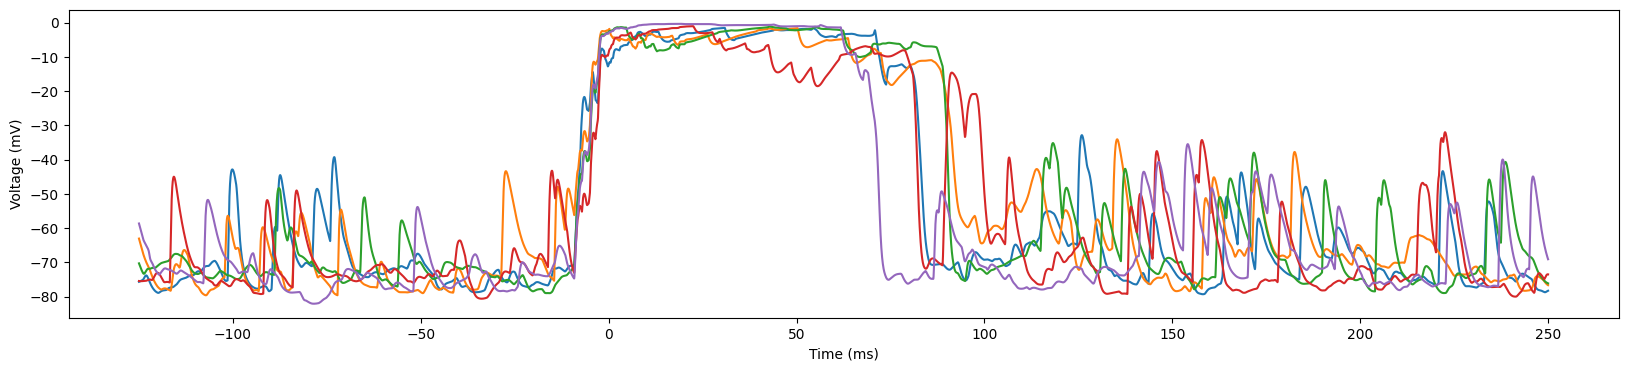

In [67]:
t_start = 15000
t_end = 30000
t_vals = np.arange(t_start, t_end)*dt-0.5
syn_num = -1
run_num = 5
plt.figure(figsize=(20,4))
plt.plot(1000*t_vals, v[0, t_start:t_end, syn_num, :].squeeze())
plt.ylabel('Voltage (mV)')
plt.xlabel('Time (ms)')
# fig, ax = plt.subplots(1,run_num,figsize=(20,8))
# fig.subplots_adjust(wspace=0)
# for i in range(run_num):
#     ax[i].plot(t_vals, v[:, t_start:t_end, syn_num, i].squeeze().T+np.arange(20)*100)
#     ax[i].plot(t_vals, soma[t_start:t_end, syn_num, i].squeeze()-100, color='k')
#     ax[i].set_yticks([])
#     #ax[i].grid(True)


Text(0.5, 0, 'Time (ms)')

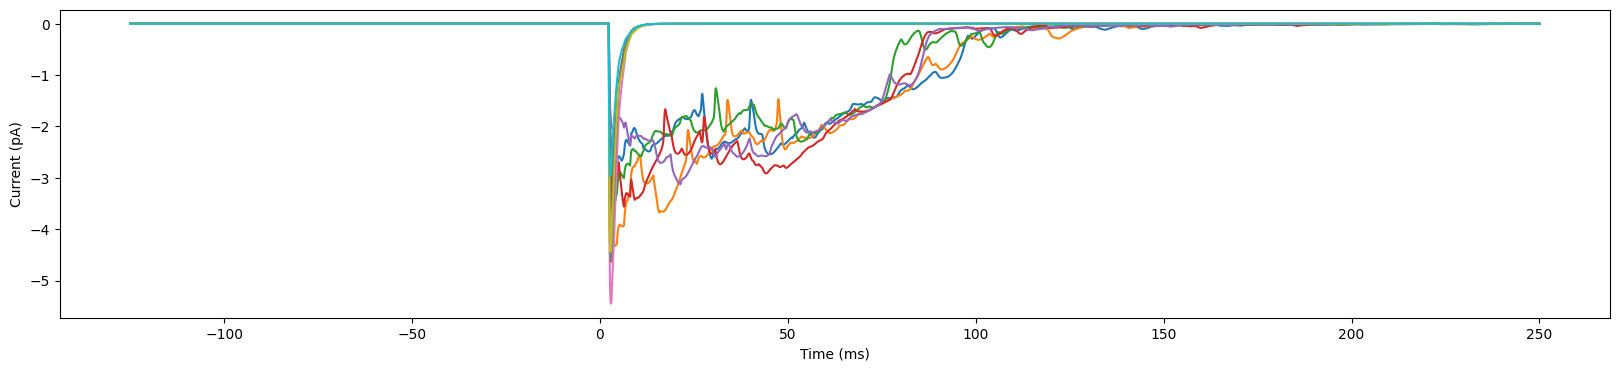

In [71]:
t_start = 15000
t_end = 30000
t_vals = np.arange(t_start, t_end)*dt-0.5
syn_num = -1
run_num = 5
plt.figure(figsize=(20,4))
plt.plot(1000*t_vals,1000*nmda[0, t_start:t_end, syn_num, :].squeeze())
plt.plot(1000*t_vals,1000*ampa[0, t_start:t_end, syn_num, :].squeeze())
plt.ylabel('Current (pA)')
plt.xlabel('Time (ms)')
# fig, ax = plt.subplots(1,run_num,figsize=(20,8))
# fig.subplots_adjust(wspace=0)
# for i in range(run_num):
#     ax[i].plot(t_vals, v[:, t_start:t_end, syn_num, i].squeeze().T+np.arange(20)*100)
#     ax[i].plot(t_vals, soma[t_start:t_end, syn_num, i].squeeze()-100, color='k')
#     ax[i].set_yticks([])
#     #ax[i].grid(True)


0.09


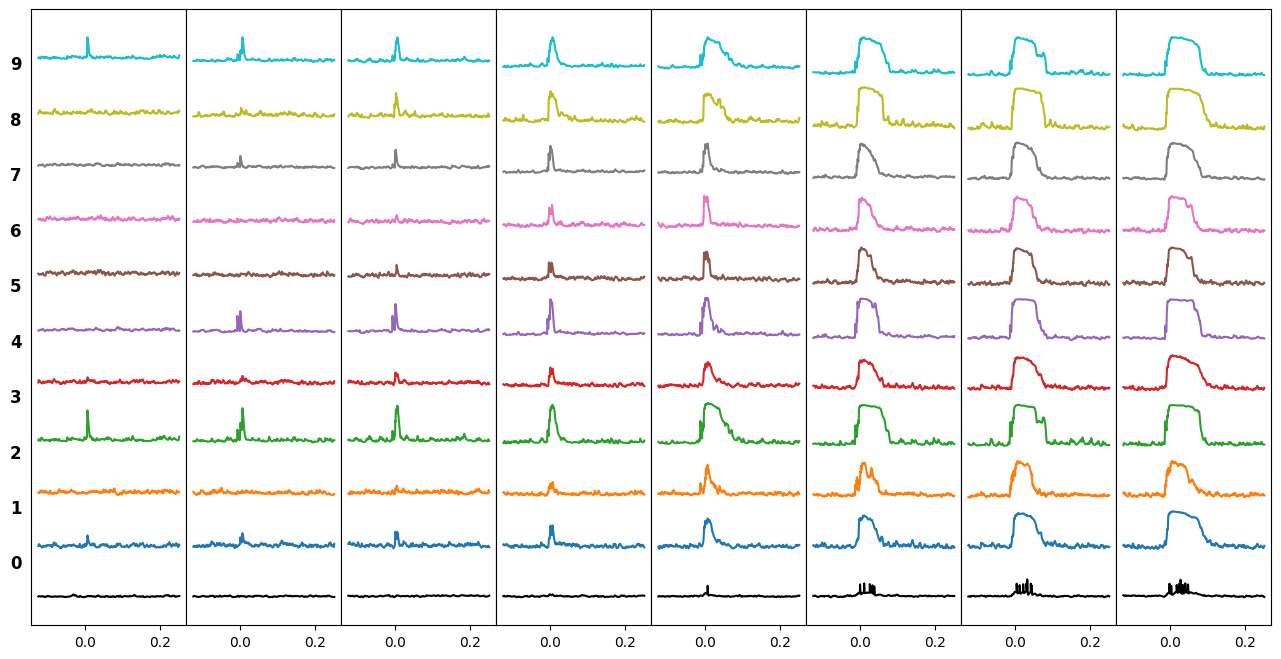

In [72]:
t_start = 15000
t_end = 30000
t_vals = np.arange(t_start, t_end)*dt-0.5
syn_num = v.shape[2] 
run_num = 1
fig, ax = plt.subplots(1,syn_num,figsize=(syn_num*2,8))

fig.subplots_adjust(wspace=0)
for i in range(syn_num):
    ax[i].plot(t_vals, np.average(v[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(v.shape[0])*100)
    ax[i].plot(t_vals, np.average(soma[t_start:t_end, i, :],axis=1).squeeze()-100, color='k')
    # ax[i].plot(t_vals, 1000*np.average(nmda[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(v.shape[0])*100,color='r')
    # ax[i].plot(t_vals, 1000*np.average(ampa[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(v.shape[0])*100,color='b')
    # ax[i].plot(t_vals, v[:, t_start:t_end, i, run_num].squeeze().T+np.arange(20)*100)
    # ax[i].plot(t_vals, soma[t_start:t_end, i, run_num].squeeze()-100, color='k')
    ax[i].set_yticks([])
    if i == 0:  # Add label only for the first subplot
        for j in range(v.shape[0]):
            # ax[i].text(-0.1, 0.1+j*0.045, str(j+1), transform=ax[i].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')
            ax[i].text(-0.1,0.1+j*(0.9*1/v.shape[0]), str(j), transform=ax[i].transAxes, va='center', ha='center', fontsize=12, fontweight='bold')
    # ax[i].grid(True)
print(0.9*1/v.shape[0])

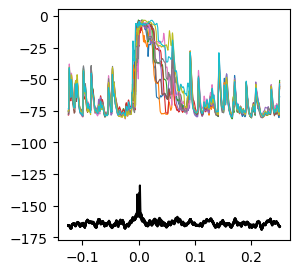

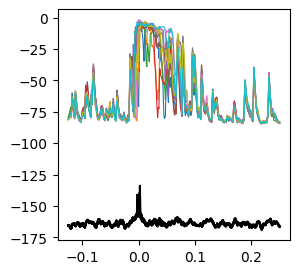

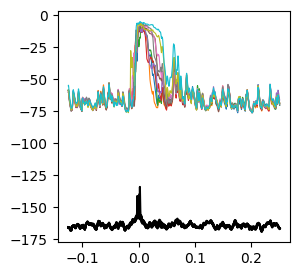

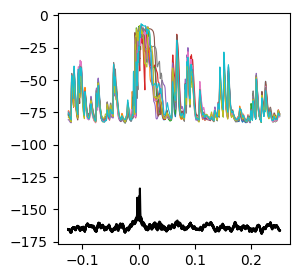

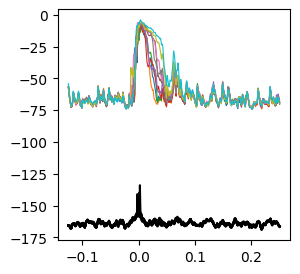

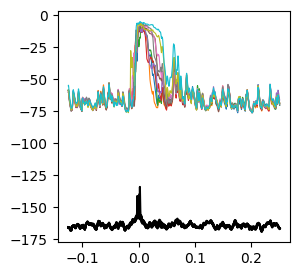

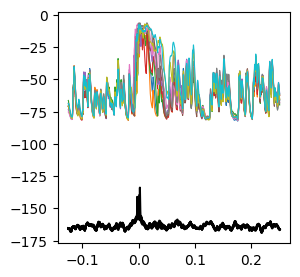

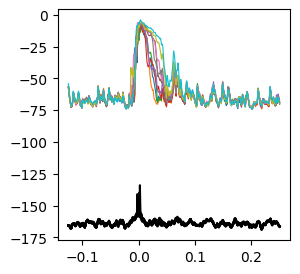

In [81]:
t_start = 15000
t_end = 30000
t_vals = np.arange(t_start, t_end)*dt-0.5
syn_num = 20
# run_num = 1
# cluster_idx = 1
cluster_idxs = [2,3,6,8,11,12,16,18]
for cluster_idx in cluster_idxs:
    fig, ax = plt.subplots(1,1,figsize=(3,3))
    fig.subplots_adjust(wspace=0)
    for i in range(syn_num)[10:]:
        # ax.plot(t_vals, np.average(v[:, t_start:t_end, i, :],axis=2).squeeze().T+np.arange(20)*100,linewidth=0.8)
        ax.plot(t_vals, np.average(v[cluster_idx, t_start:t_end, i, :],axis=1).squeeze().T,linewidth=0.8)
        ax.plot(t_vals, np.average(soma[t_start:t_end, i, :],axis=1).squeeze()-100, color='k')
        # ax[i].plot(t_vals, v[:, t_start:t_end, i, run_num].squeeze().T+np.arange(20)*100)
        # ax[i].plot(t_vals, soma[t_start:t_end, i, run_num].squeeze()-100, color='k')
        # ax.set_yticks([])
        # ax[i].grid(True)


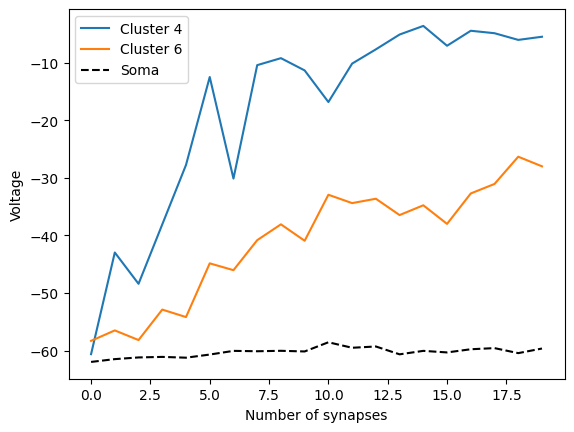

In [92]:
# dend_v_peak = np.max(np.mean(v, axis=3)[:,20000:24000,:], axis=1)
# soma_v_peak = np.max(np.mean(soma, axis=2)[20000:24000,:], axis=0)

t_stim = 20000
peak_dur = 500 # 40 ms (1000 * 1600/40000)

dend_v_peak = np.mean(np.mean(v, axis=3)[:,t_stim:t_stim+peak_dur,:], axis=1)
soma_v_peak = np.mean(np.mean(soma, axis=2)[t_stim:t_stim+peak_dur,:], axis=0)

cluster_idxs = [3,5]
plt.figure()
# for cluster_index in range(v.shape[0])[:10]:
for cluster_idx in cluster_idxs:
    plt.plot(dend_v_peak[cluster_idx, :], label=f"Cluster {cluster_idx + 1}")
plt.plot(soma_v_peak, linestyle='dashed', label="Soma",color='k')

plt.xlabel("Number of synapses")
plt.ylabel("Voltage")
plt.legend()